In [1]:
# =========================
# Cell 1 : Import Libraries
# =========================

# Basic Libraries
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [2]:
# =========================
# Cell 2 : Load Dataset
# =========================

# Load dataset
df = pd.read_csv("water_potability.csv")

# Display basic information
print("Dataset Shape:", df.shape)

# First 5 rows
df.head()

Dataset Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# =========================
# Cell 3 : Dataset Information
# =========================

# Dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [4]:
# =========================
# Cell 4 : Check Missing Values
# =========================

# Check missing values in each column
print("Missing Values in Each Column:")
df.isnull().sum()

Missing Values in Each Column:


ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [5]:
# =========================
# Cell 5 : Handle Missing Values
# =========================

# Fill missing values with column mean
df.fillna(df.mean(), inplace=True)

# Verify missing values after filling
print("Missing Values After Filling:")
df.isnull().sum()

Missing Values After Filling:


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

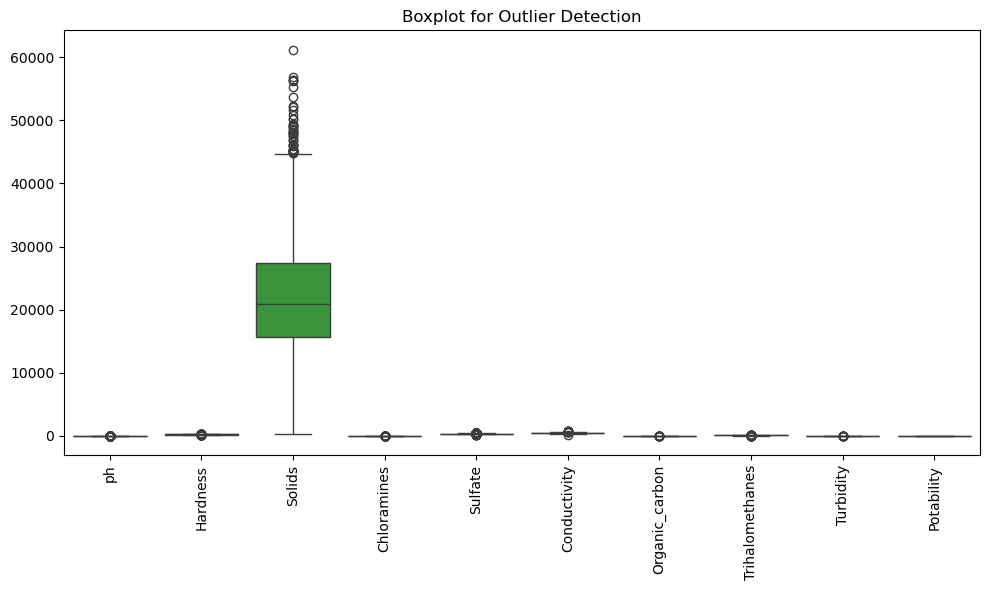

In [6]:
# =========================
# Cell 6 : Boxplot for Outlier Detection
# =========================

# Create boxplot for all numerical columns
plt.figure(figsize=(10, 6))

sns.boxplot(data=df)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Add title
plt.title("Boxplot for Outlier Detection")

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

In [7]:

# Optional clipping
df = df.clip(lower=df.quantile(0.01), upper=df.quantile(0.99), axis=1)

In [8]:
# =========================
# Cell 7 : Complete Data Cleaning
# =========================

# 1. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 2. Fill missing values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# 3. Check data types
print("Data Types:\n")
print(df.dtypes)

# 4. Verify missing values after cleaning
print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())

# 5. Verify duplicate rows after cleaning
print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

# 6. Final dataset shape
print("\nFinal Dataset Shape:")
print(df.shape)

# 7. Preview cleaned dataset
df.head()

Data Types:

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Missing Values After Cleaning:

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Duplicate Rows After Cleaning:
0

Final Dataset Shape:
(3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


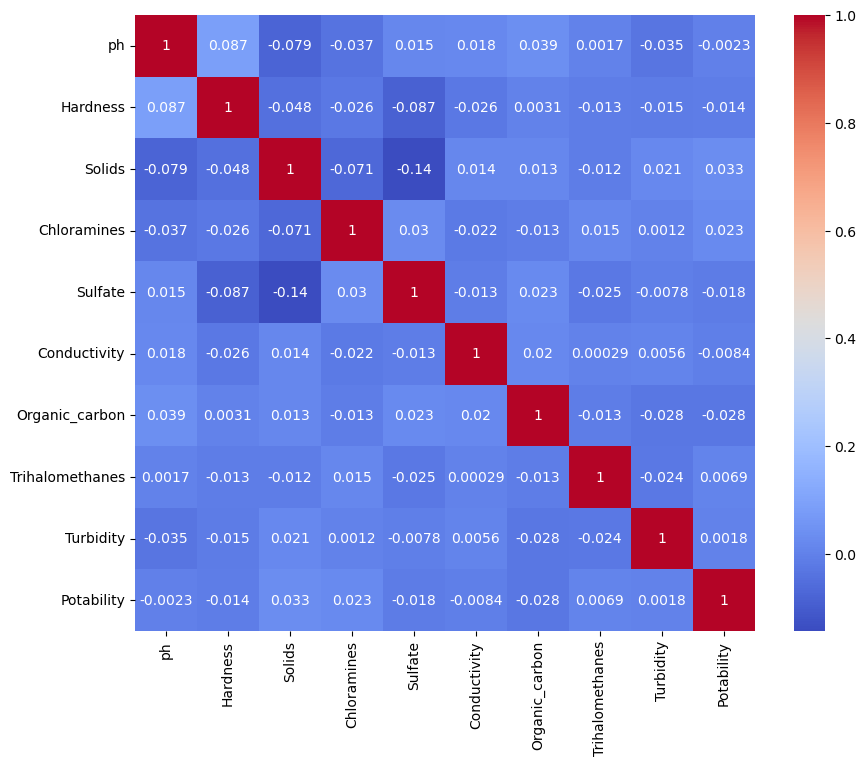

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

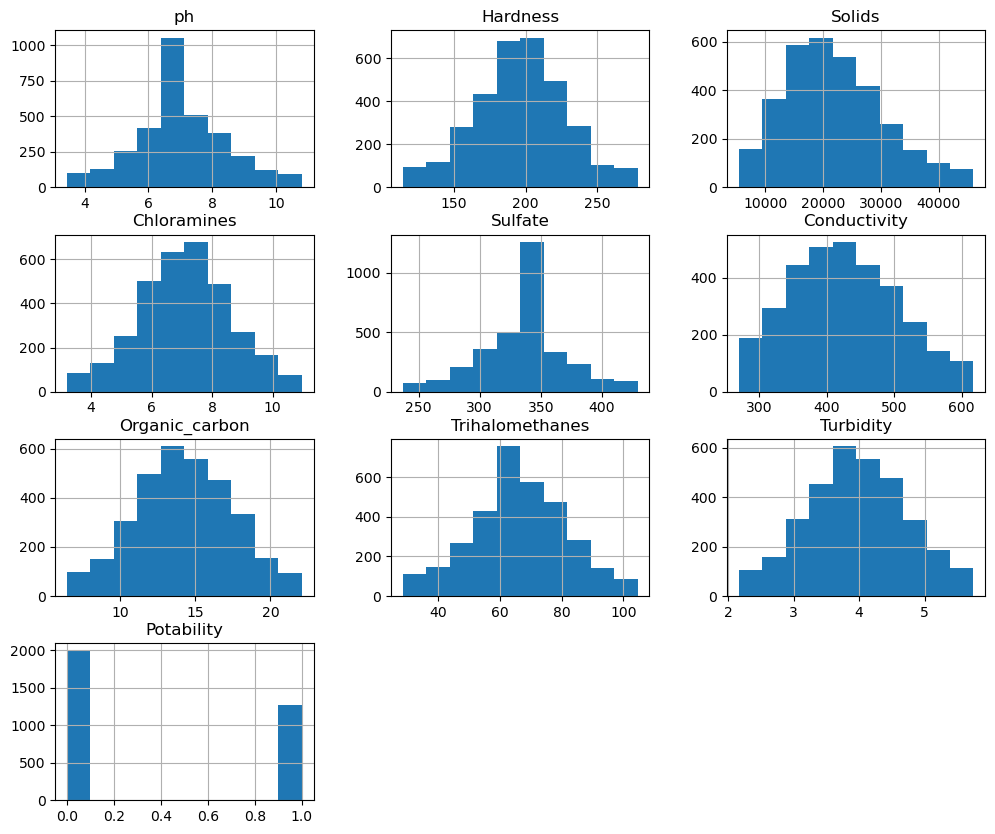

In [10]:
df.hist(figsize=(12,10))
plt.show()

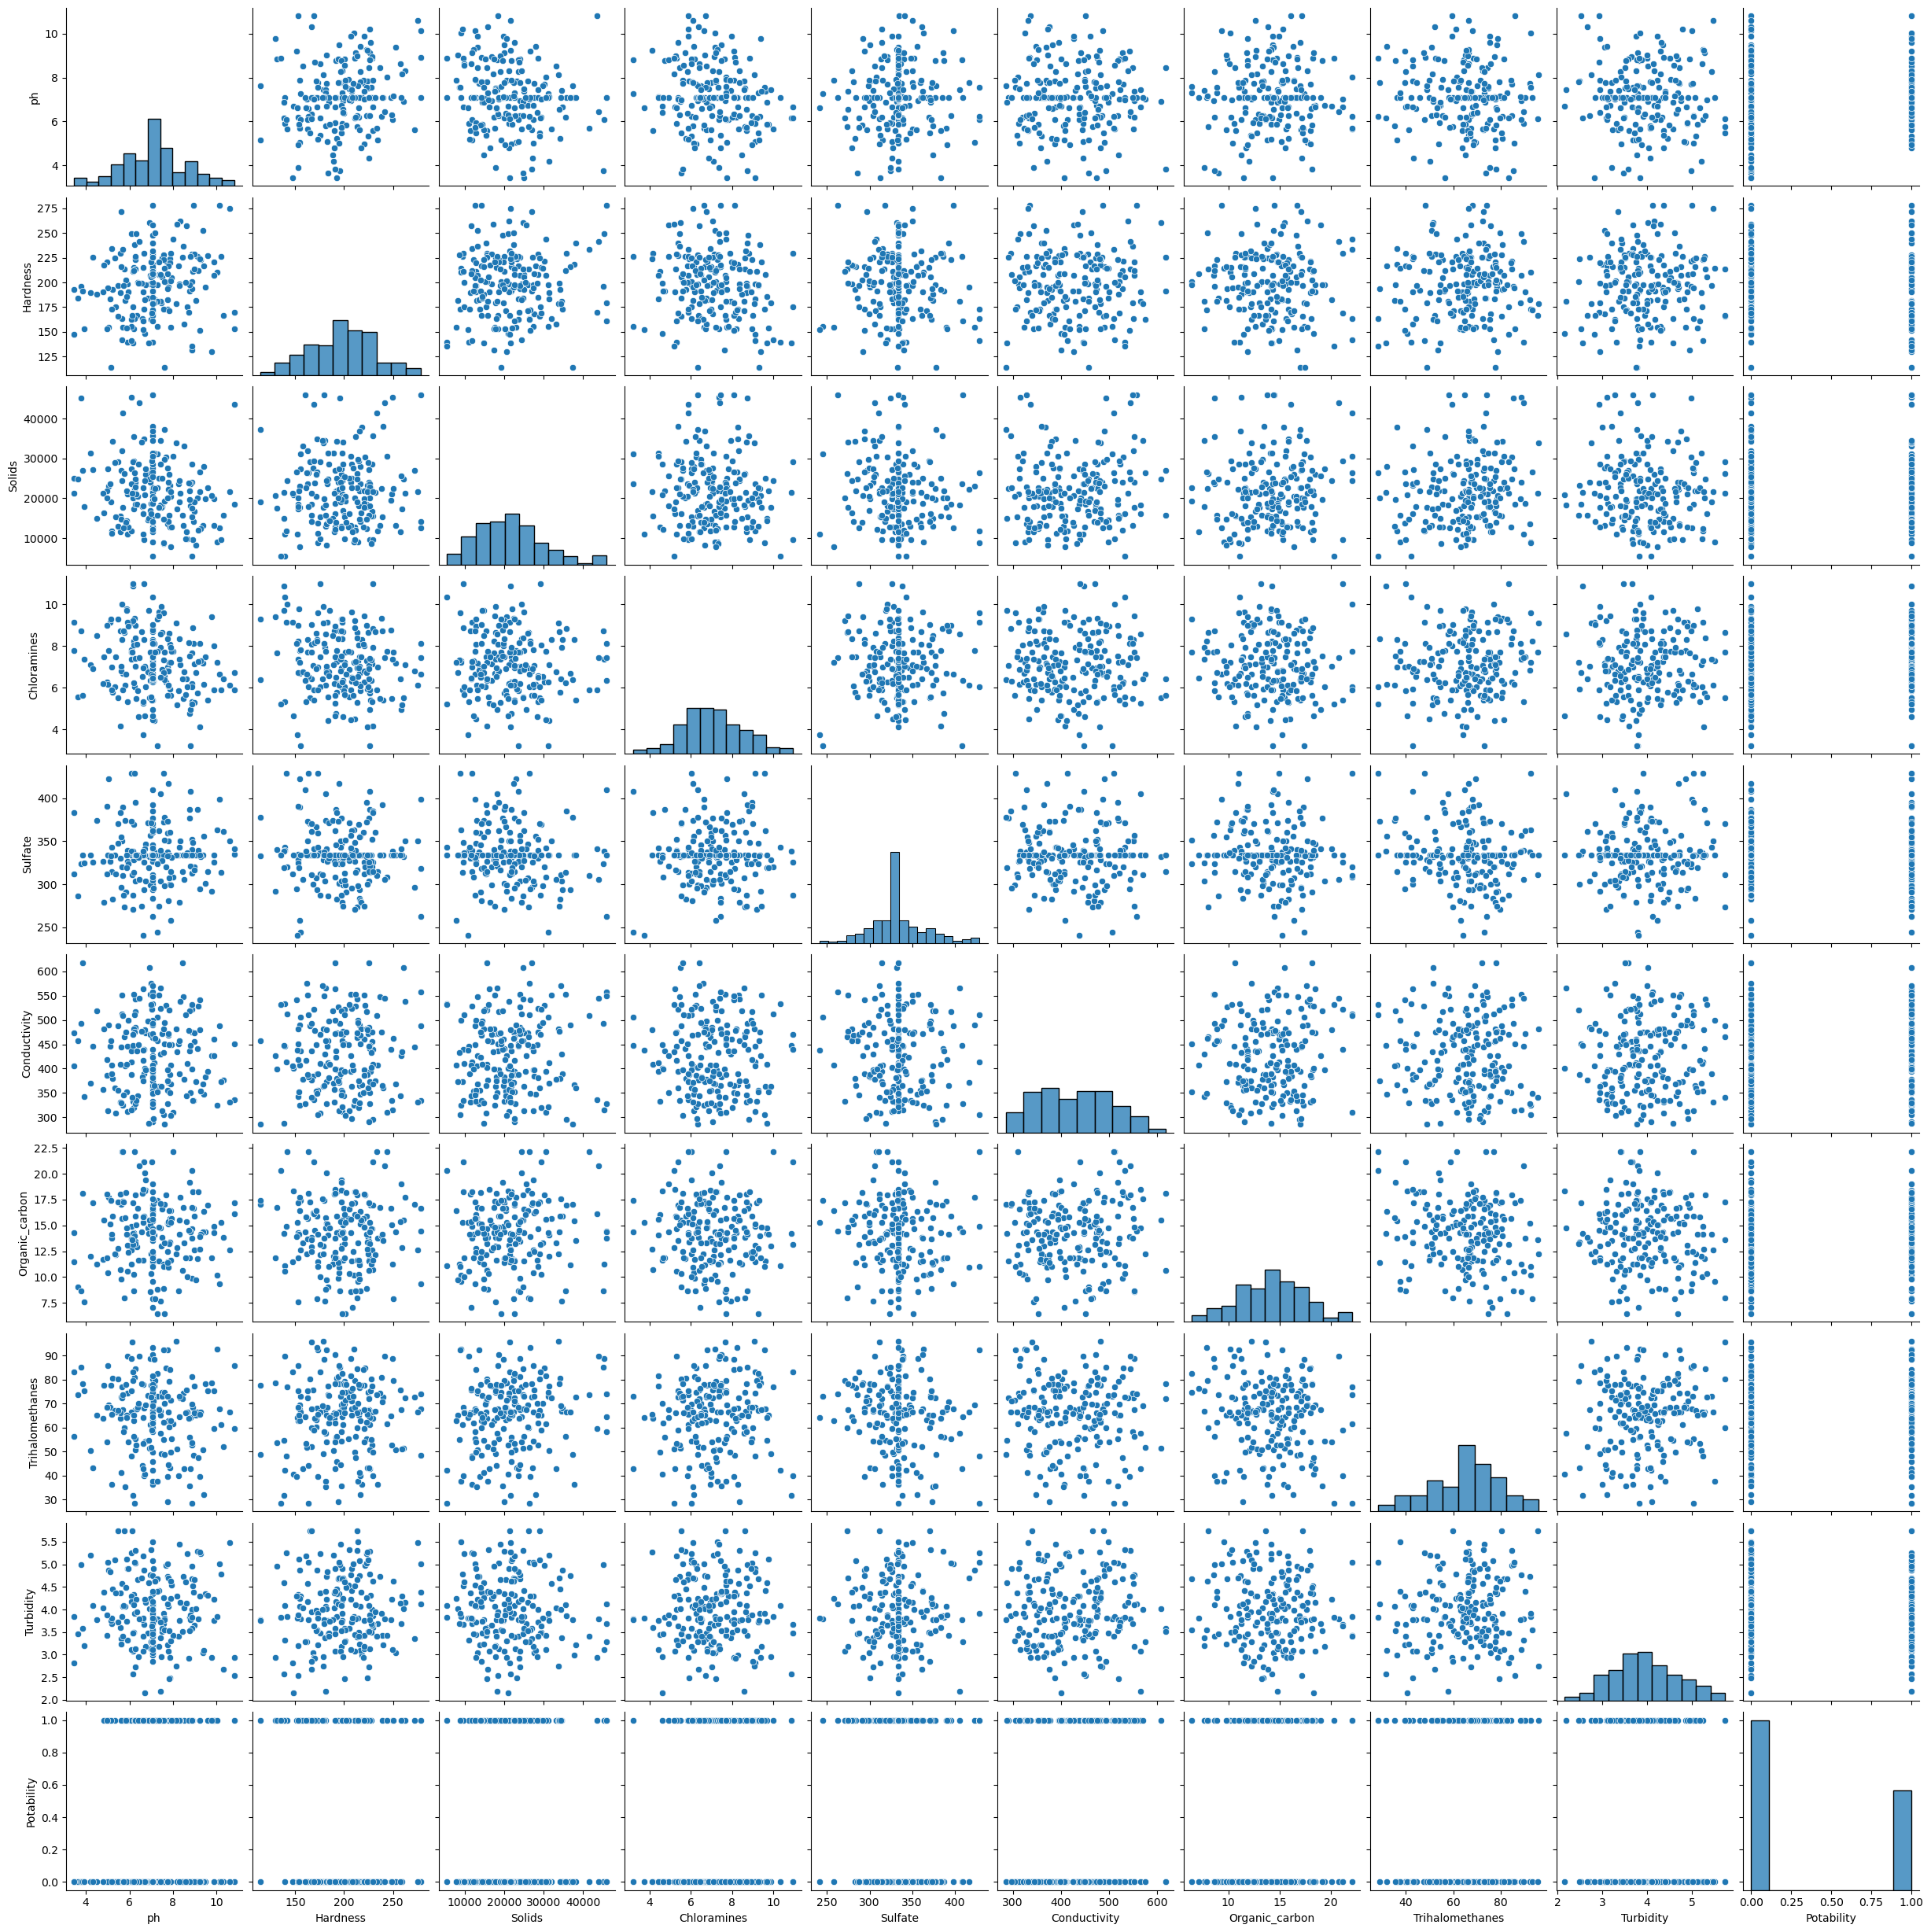

In [11]:
sns.pairplot(df.sample(200))
plt.show()

In [12]:
features = ['ph', 'Hardness', 'Solids', 'Sulfate', 'Conductivity', 'Turbidity']
X = df[features]
y = df['Potability']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [16]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [17]:
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [18]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [19]:
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)
dt_acc = accuracy_score(y_test, dt_pred)

print(lr_acc, rf_acc, svm_acc, dt_acc)

0.6280487804878049 0.6570121951219512 0.6661585365853658 0.5853658536585366


In [23]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

# Predictions
y_pred = best_rf.predict(X_test)

print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 0.6783536585365854


In [22]:
df['ph_ratio'] = df['ph'] / df['Hardness']
df['solid_conductivity'] = df['Solids'] / df['Conductivity']
df['turbidity_ph'] = df['Turbidity'] * df['ph']

In [28]:
features = ['ph', 'Hardness', 'Solids', 'Sulfate', 'Conductivity', 'Turbidity',
            'ph_ratio', 'solid_conductivity', 'turbidity_ph']

In [29]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [31]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42
)

In [32]:
for col in df.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df = df[(df[col] >= lower) & (df[col] <= upper)]

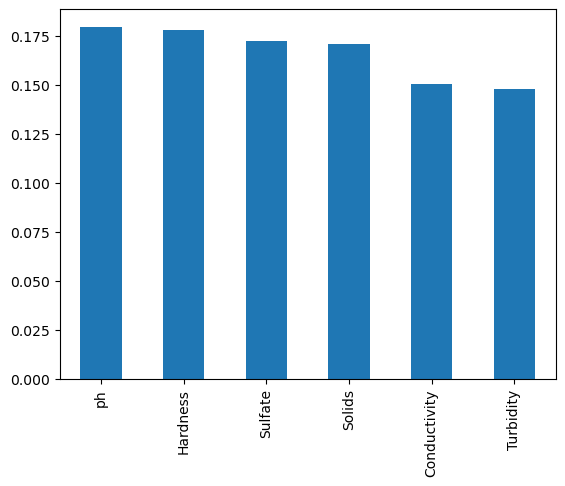

In [29]:
rf.fit(X_train, y_train)

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp.sort_values(ascending=False).plot(kind='bar')
plt.show()

In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_train, y_train, cv=5)

print("CV Accuracy:", scores.mean())

CV Accuracy: 0.7077711815991455


In [31]:
import joblib

joblib.dump(best_rf, "water_quality_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [33]:
sample = [[7.5, 180, 15000, 320, 420, 4.2]]

sample_scaled = scaler.transform(sample)

prediction = best_rf.predict(sample_scaled)

print("Water is Potable ✅" if prediction[0] == 1 else "Water is NOT Potable ❌")

Water is NOT Potable ❌


C:\Users\adity\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
